In [1]:
!pip install tensorflow matplotlib pillow

In [13]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import warnings
warnings.filterwarnings(action="ignore")

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    r"C:\Users\kusuma\Desktop\potato_leaf_disease_detection",
    image_size=(128, 128),
    batch_size=32
)

Found 2152 files belonging to 3 classes.


In [4]:
# Check Class Names

In [5]:
class_names = dataset.class_names

print(class_names)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [6]:
# Display Sample Image

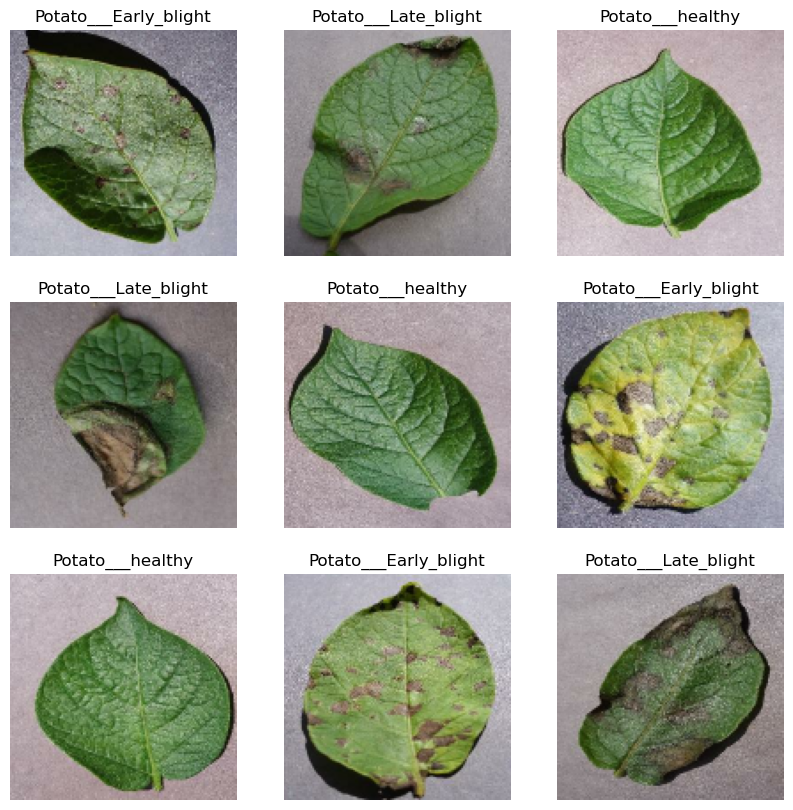

In [7]:
plt.figure(figsize=(10,10))

for images, labels in dataset.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

In [8]:
# this is image data set for CNN

In [9]:
# Split Data Set

In [10]:
dataset_size = len(dataset)

train_size = int(0.8 * dataset_size)

test_size = int(0.2 * dataset_size)

train_dataset = dataset.take(train_size)

test_dataset = dataset.skip(train_size)

In [11]:
# Build CNN Model

In [14]:
model = tf.keras.models.Sequential([

    # RESCALING
    tf.keras.layers.Rescaling(1./255),

    # CNN LAYER 1
    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    ),

    tf.keras.layers.MaxPooling2D(),

    # CNN LAYER 2
    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(),

    # CNN LAYER 3
    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(),

    # FLATTEN
    tf.keras.layers.Flatten(),

    # DENSE
    tf.keras.layers.Dense(
        64,
        activation='relu'
    ),

    # OUTPUT
    tf.keras.layers.Dense(
        3,
        activation='softmax'
    )

])

In [15]:
# Compile Model

In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
# Train Model

In [18]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=5
)

Epoch 1/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 29s 436ms/step - accuracy: 0.6302 - loss: 0.7661 - val_accuracy: 0.8420 - val_loss: 0.4783
Epoch 2/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 15s 269ms/step - accuracy: 0.8646 - loss: 0.3990 - val_accuracy: 0.8750 - val_loss: 0.3232
Epoch 3/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 15s 273ms/step - accuracy: 0.8796 - loss: 0.2987 - val_accuracy: 0.8892 - val_loss: 0.3311
Epoch 4/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 267ms/step - accuracy: 0.9115 - loss: 0.2487 - val_accuracy: 0.9434 - val_loss: 0.1763
Epoch 5/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 16s 299ms/step - accuracy: 0.9346 - loss: 0.1794 - val_accuracy: 0.9575 - val_loss: 0.1217


In [20]:
print("Final Training Accuracy:",
      history.history['accuracy'][-1])

print("Final Validation Accuracy:",
      history.history['val_accuracy'][-1])

Final Training Accuracy: 0.9346064925193787
Final Validation Accuracy: 0.9575471878051758


In [21]:
model.save("potato_disease_model.h5")

print("Model saved successfully!")

Model saved successfully!
